In [3]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline

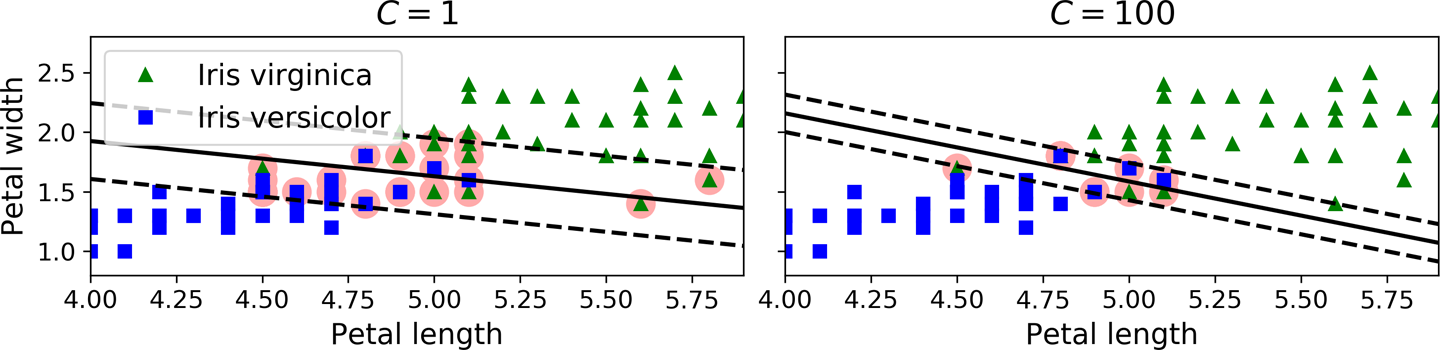

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn import datasets
import numpy as np

# Load the Iris dataset (150 samples, 4 features, 3 classes)
iris = datasets.load_iris()

# Select only two features: petal length (index 2) and petal width (index 3)
# This reduces the problem to a 2-dimensional feature space
X = iris["data"][:, (2, 3)]

# Convert the 3-class target into a binary classification problem targeting Iris Virginica
# True becomes 1.0, False becomes 0.0
y = (iris["target"] == 2).astype(np.float64)

# Build an ML pipeline consisting of:
# 1. StandardScaler: standardizes features to mean=0, std=1
# 2. LinearSVC: linear Support Vector Classifier using hinge loss
#    C=1 controls regularization strength (balance between margin size and misclassification)
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge"))
])



In [5]:
svm_clf.fit(X, y)

,steps,"[('scaler', ...), ('linear_svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001


In [6]:
svm_clf.predict([[5.5, 1.7]])

array([1.])

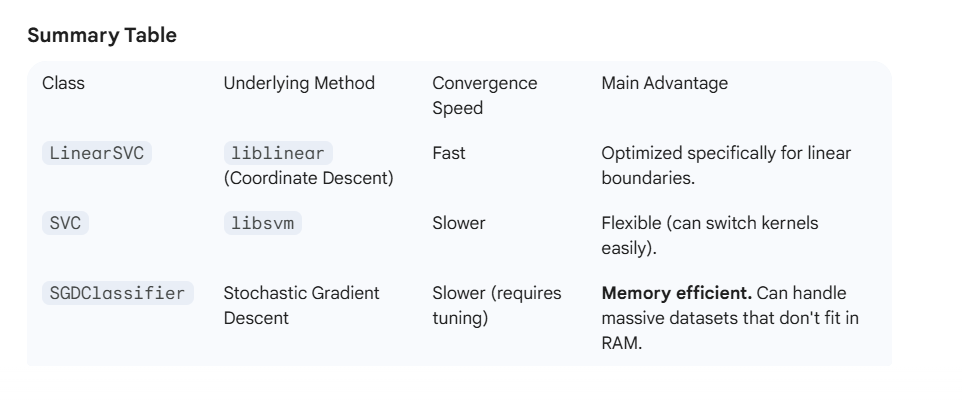

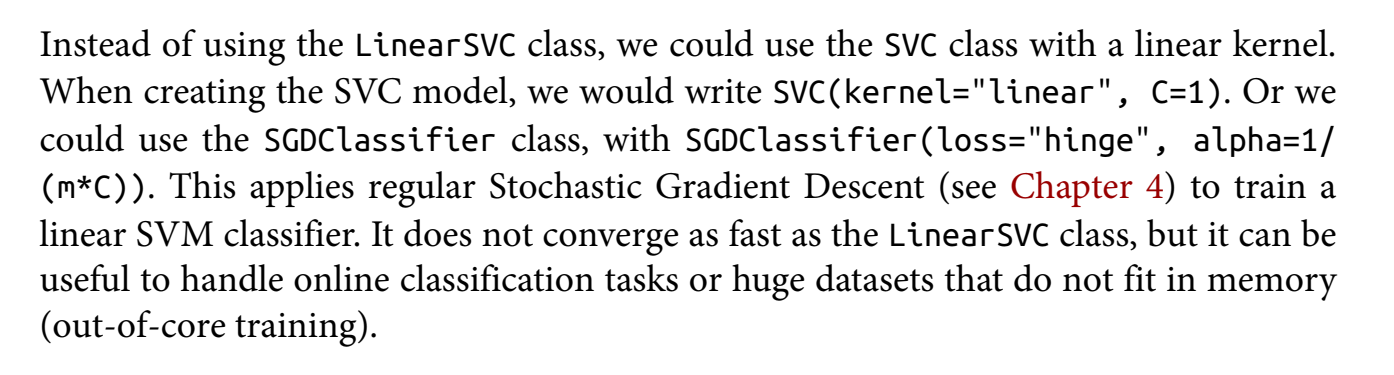

## Nonlinear SVM Classification

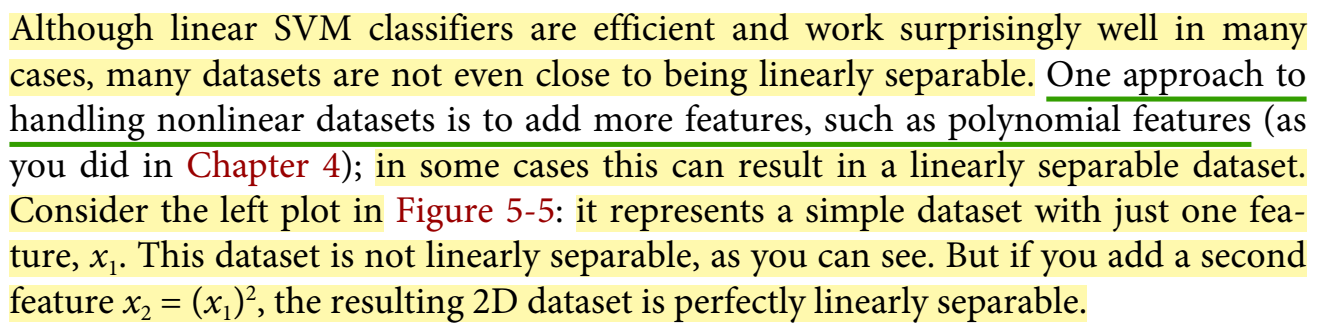

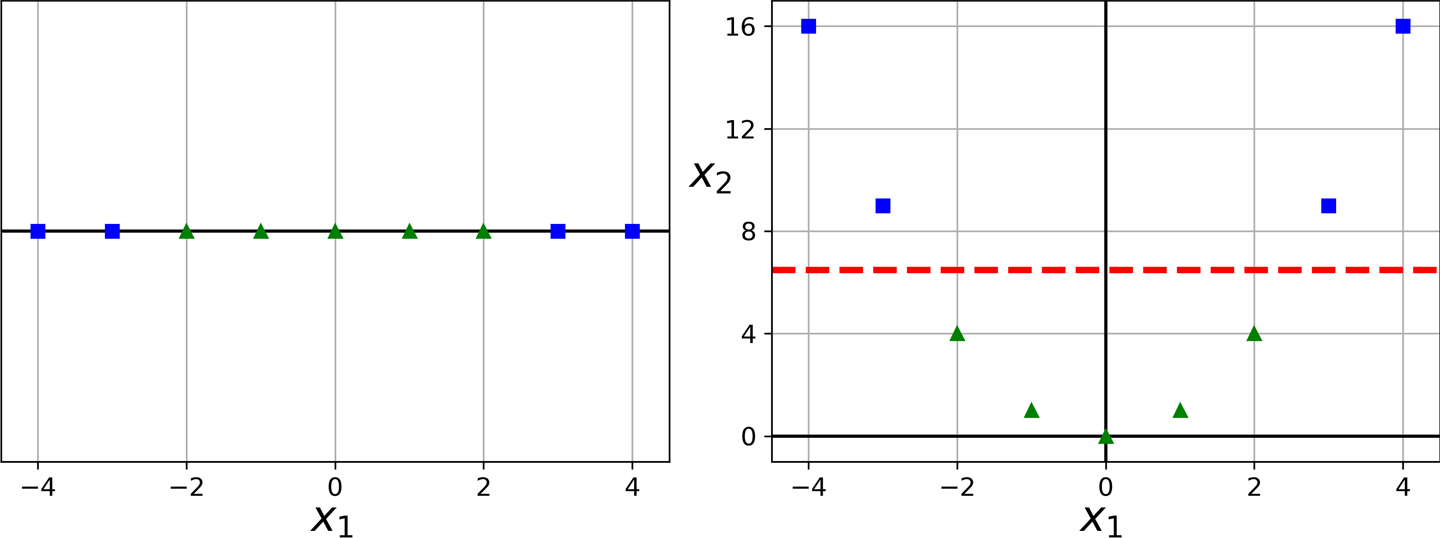

In [7]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

# Generate a synthetic 2D dataset shaped like two interleaving half-moons.
# n_samples=100: number of points
# noise=0.15: adds Gaussian noise to make the classification problem more realistic and nonlinear
X, y = make_moons(n_samples=100, noise=0.15)

# Build a pipeline for a Polynomial SVM classifier
polynomial_svm_clf = Pipeline([
    # Step 1: Polynomial feature expansion
    # Transforms the original features (x1, x2) into polynomial combinations:
    # e.g. x1^2, x1*x2, x2^2, x1^3, ...
    # This enables a linear SVM to learn a nonlinear decision boundary.
    ("poly_features", PolynomialFeatures(degree=3)),
    
    # Step 2: StandardScaler
    # Standardizes features so they have mean=0 and std=1.
    # Essential for SVMs because they are sensitive to feature scaling.
    ("scaler", StandardScaler()),
    
    # Step 3: Linear SVM classifier
    # C=10: stronger emphasis on minimizing classification errors
    # loss="hinge": standard hinge loss used in classical SVM formulation
    ("svm_clf", LinearSVC(C=10, loss="hinge"))
])

# Train (fit) the entire pipeline on the dataset
# Pipeline applies: polynomial expansion → scaling → SVM fitting
polynomial_svm_clf.fit(X, y)


i:\programs installed\miniConda\envs\pytorch\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,steps,"[('poly_features', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [9]:
polynomial_svm_clf.predict([[5.5, 1.7]])

array([1])

## Polynomial Kernel

* Adding polynomial features is simple to implement and can work great with all sorts of Machine Learning algorithms (not just SVMs). 
* That said, at a low polynomial degree, this method cannot deal with very complex datasets, and with a high polynomial degree it creates a huge number of features, making the model too slow.
* Fortunately, when using SVMs you can apply an almost miraculous mathematical technique called the kernel trick (explained in a moment). 
* The kernel trick makes it possible to get the same result as if you had added many polynomial features, even with very high-degree polynomials, without actually having to add them So there is no combinatorial explosion of the number of features because you don’t actually add any features. 

In [13]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Build an SVM classifier using a Polynomial Kernel
poly_kernel_svm_clf = Pipeline([
    # Step 1: Standardize all features
    # SVMs (especially kernel SVMs) are highly sensitive to feature scaling.
    # StandardScaler transforms each feature to:
    #   mean = 0
    #   standard deviation = 1
    # This ensures that all features contribute equally to the kernel computation.
    ("scaler", StandardScaler()),

    # Step 2: Kernel SVM with a Polynomial Kernel
    # SVC: Support Vector Classification using kernels.
    # kernel="poly": This applies the polynomial kernel function:
    #
    #   K(x, z) = (gamma * <x, z> + coef0)^degree
    #
    # For polynomial kernels:
    #   degree=3   → cubic decision boundary
    #   coef0=1    → controls how much the higher-order terms matter
    #   C=5        → regularization strength
    #
    # Explanation of key parameters:
    #
    # degree=3:
    #   - Allows the model to learn nonlinear boundaries up to cubic interactions.
    #   - Suitable for the "moons" dataset, which is moderately nonlinear.
    #
    # coef0=1:
    #   - Influences how the kernel weights lower vs. higher-order polynomial terms.
    #   - Higher coef0 → less influence from high-degree interaction terms.
    #
    # C=5:
    #   - Medium-high regularization; the model penalizes misclassifications moderately.
    #   - Higher C forces the SVM to fit the training data more tightly.
    #
    ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
])

# Train the pipeline
# Pipeline applies:
#   1. Standardization
#   2. Polynomial kernel SVM classification
poly_kernel_svm_clf.fit(X, y)


,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,5
,kernel,'poly'
,degree,3
,gamma,'scale'


In [14]:
poly_kernel_svm_clf.predict([[5.5, 1.7]])

array([1])

if your model is overfitting, you might want to
reduce the polynomial degree. Conversely, if it is underfitting, you can try increasing
it. The hyperparameter `coef0` controls how much the model is influenced by highdegree polynomials versus low-degree polynomials.

**note:**
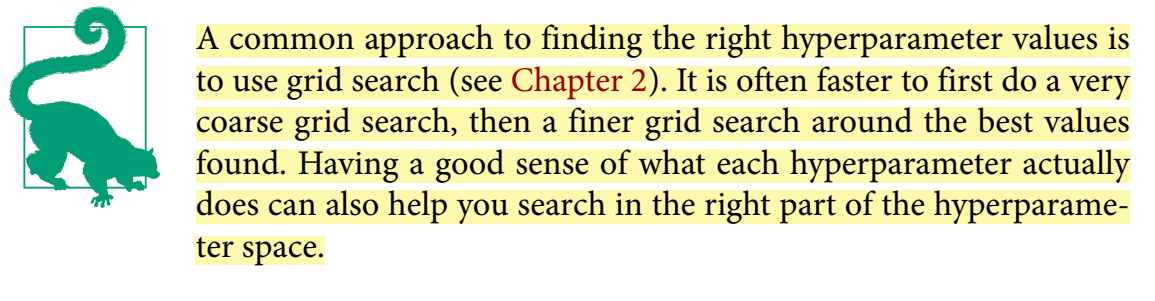

In [15]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Build an SVM classifier using the RBF (Gaussian) kernel
rbf_kernel_svm_clf = Pipeline([
    # Step 1: Standard scaling of input features
    # SVM kernels (especially RBF) are extremely sensitive to the scale of features.
    # StandardScaler ensures each feature has:
    #   - mean = 0
    #   - standard deviation = 1
    # Without scaling, the RBF kernel would behave unpredictably and distort distances.
    ("scaler", StandardScaler()),

    # Step 2: Kernel SVM using the RBF kernel
    # SVC(kernel="rbf") uses the Gaussian Radial Basis Function:
    #
    #     K(x, z) = exp(-γ * ||x - z||²)
    #
    # This kernel measures similarity based on Euclidean distance.
    # The closer two points are, the closer the kernel value is to 1.
    # The farther two points are, the kernel value decays toward 0.
    #
    # Parameters:
    # --------------------------------------------------------------
    # gamma=5:
    #   Controls the "influence range" of each training sample.
    #   High gamma → very narrow Gaussian → model becomes highly sensitive to small variations.
    #   Low gamma → wide Gaussian → smooth, broad decision boundary.
    #
    #   gamma=5 is relatively high for 2D data:
    #     → sharp, local decision boundaries
    #     → risk of overfitting (model memorizes local fluctuations)
    #
    # C=0.001:
    #   Regularization parameter.
    #   Very small C = very strong regularization.
    #
    #   This encourages:
    #     - A very smooth, wide-margin decision boundary
    #     - Many training points may be misclassified
    #     - Underfitting is likely
    #
    # Combined effect:
    #   gamma=5 (complex patterns)
    #   C=0.001 (heavy smoothing)
    #
    #   These two parameters fight each other:
    #     gamma pushes for high complexity
    #     C forces extreme simplicity
    #
    #   Net result:
    #     → A smooth, nearly linear or very broad curved boundary
    #     → Many training errors tolerated
    #
    ("svm_clf", SVC(kernel="rbf", gamma=5, C=0.001))
])

# Fit the entire pipeline:
# 1. Standardization
# 2. RBF kernel SVM training
rbf_kernel_svm_clf.fit(X, y)


,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,0.001
,kernel,'rbf'
,degree,3
,gamma,5


### SVM Regression

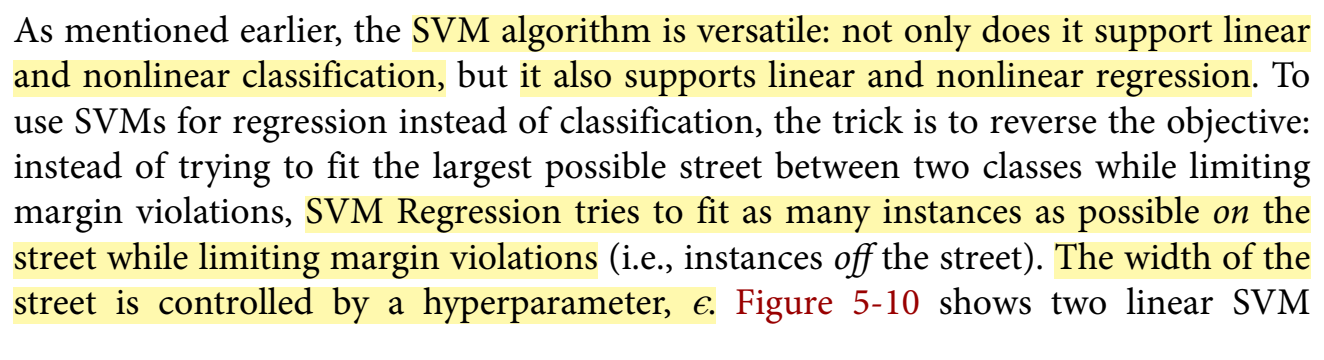

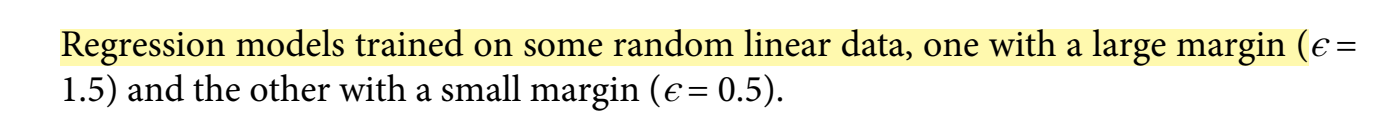

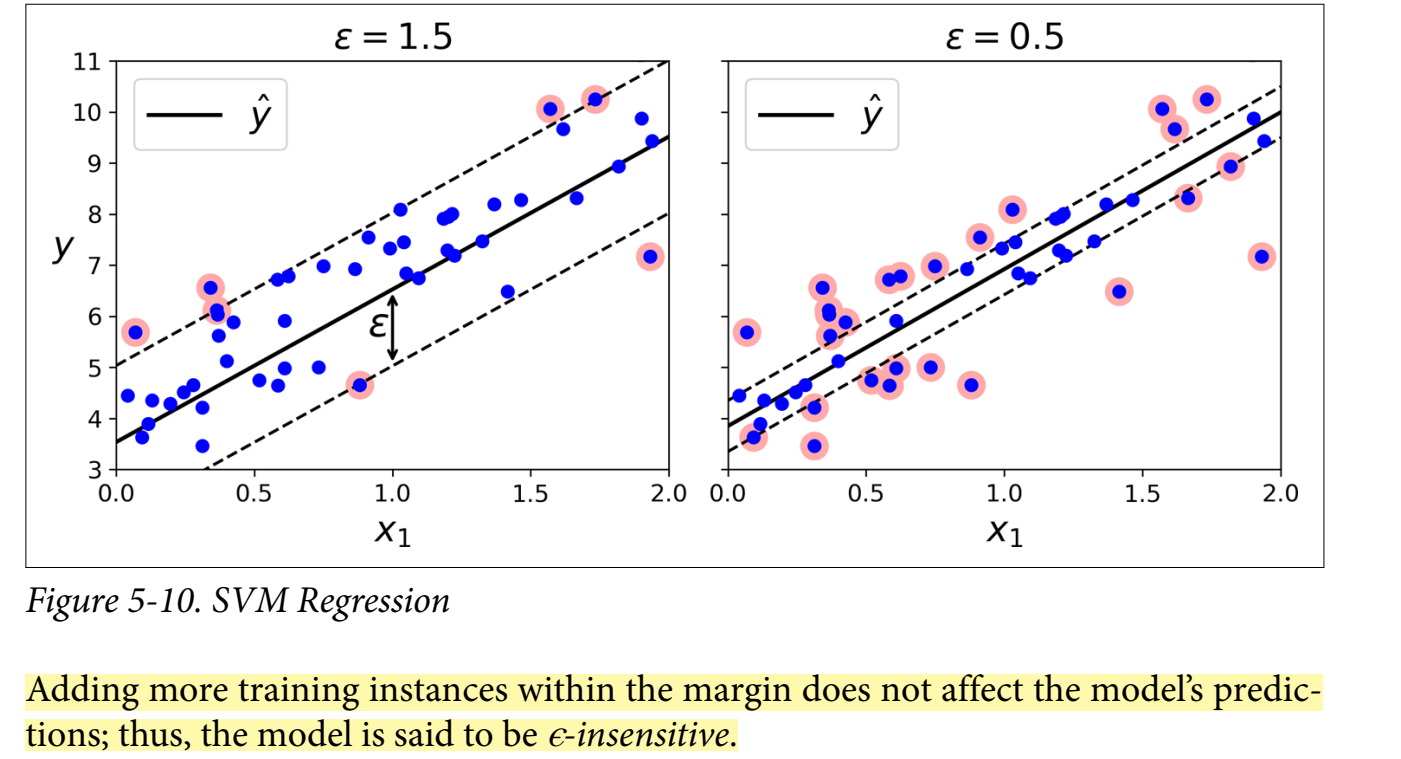

In [15]:
from sklearn.svm import LinearSVR
svm_reg = LinearSVR(epsilon=1.5)
svm_reg.fit(X, y)

C:\Users\Khalid\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVR(epsilon=1.5)

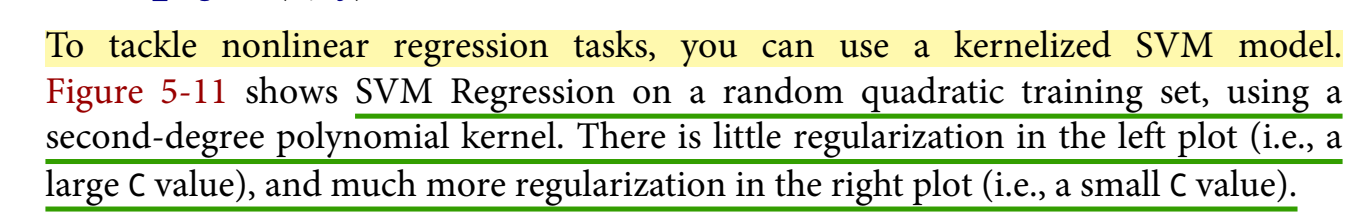

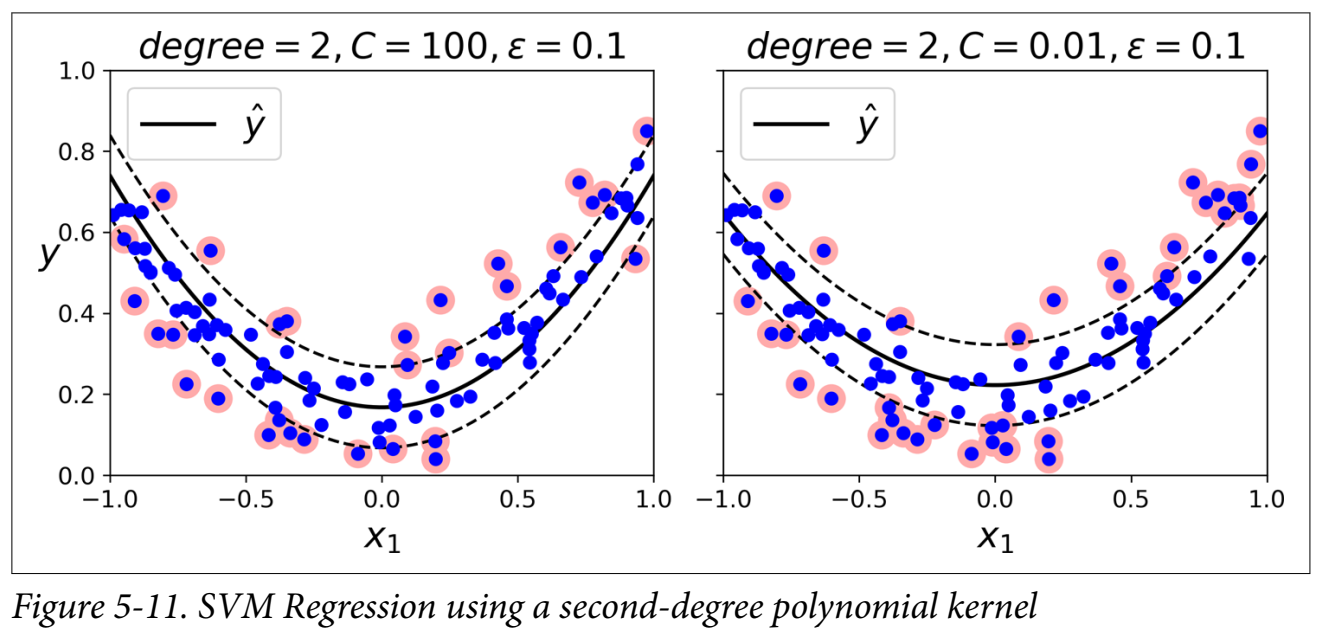

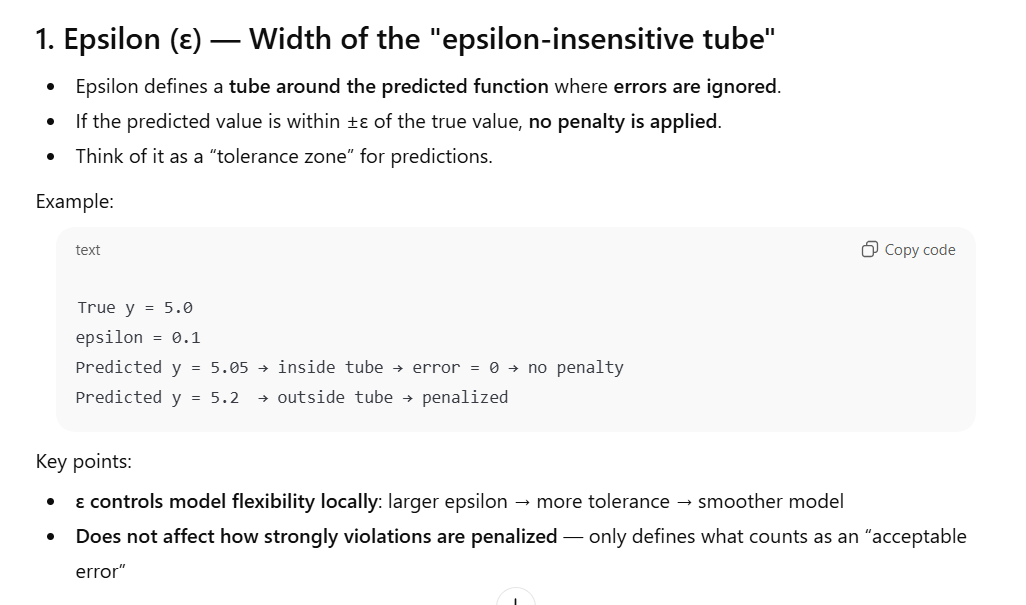

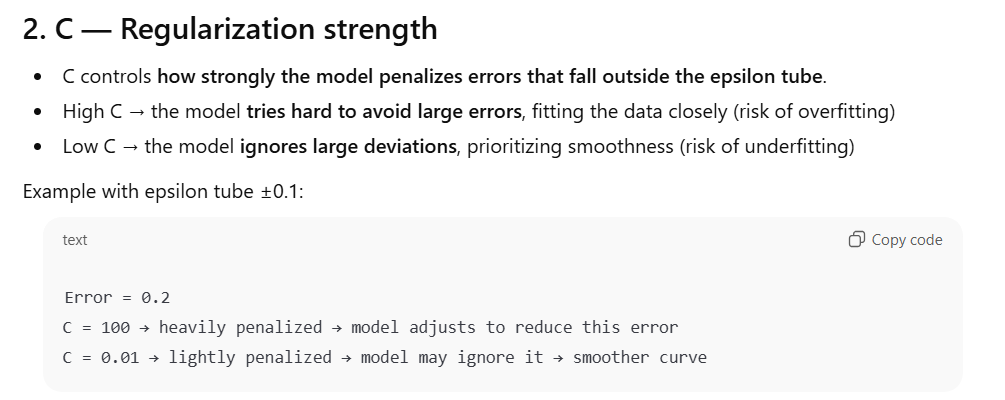

In [ ]:
from sklearn.svm import SVR  # Import Support Vector Regression model from scikit-learn

# Create an SVR model using a polynomial kernel
svm_poly_reg = SVR(
    kernel="poly",   # Use a polynomial kernel instead of linear or RBF.
                     # Polynomial kernels allow the model to fit curved relationships.

    degree=2,        # Degree of the polynomial. A quadratic polynomial (degree=2)
                     # adds features like x1^2, x2^2, and interaction terms.
                     # Higher degrees give more complexity but risk overfitting.

    C=100,           # Regularization strength (same concept as in SVM classification).
                     # Larger C reduces regularization → the model fits training data more strictly,
                     # risking overfitting but lowering training error.

    epsilon=0.1      # Width of the epsilon-insensitive tube.
                     # If prediction error is within ±0.1, it is NOT penalized.
                     # A larger epsilon allows more tolerance → smoother model.
)

# Fit the SVR model on the dataset
svm_poly_reg.fit(X, y)
# Here:
#   X = 2D feature matrix (e.g., coordinates from make_moons or any regression dataset)
#   y = 1D continuous target values representing what we want to predict
#
# The model learns a nonlinear regression function shaped by the polynomial kernel.


SVR(C=100, degree=2, kernel='poly')